In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Feature Engineering & Extraction

In [5]:
df_cleaned = pd.read_csv('insurance_cleaned_data.csv')

In [6]:
df_cleaned

,age,ismale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1332,50,0,30,3,0,10600,1,0,0
1333,18,1,31,0,0,2205,0,0,0
1334,18,1,36,0,0,1629,0,1,0
1335,21,1,25,0,0,2007,0,0,1


<Axes: xlabel='bmi', ylabel='Count'>

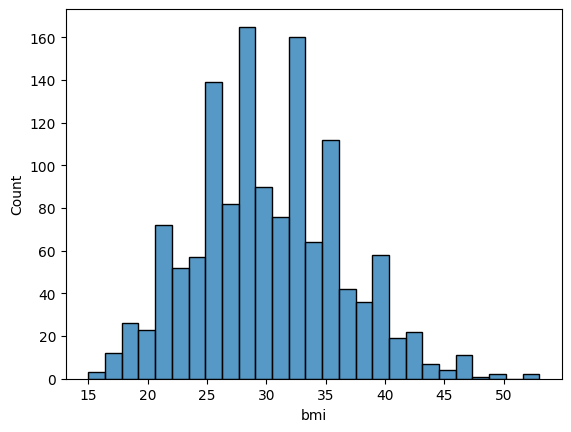

In [7]:
sns.histplot(df_cleaned['bmi'])

In [8]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'], bins=[0,18.5,24.9,29.9,float('inf')],
    labels = ['underweight','normal','overweight','abese']
    )

In [9]:
df_cleaned

,age,ismale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,abese
2,28,0,33,3,0,4449,0,1,0,abese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1332,50,0,30,3,0,10600,1,0,0,abese
1333,18,1,31,0,0,2205,0,0,0,abese
1334,18,1,36,0,0,1629,0,1,0,abese
1335,21,1,25,0,0,2007,0,0,1,overweight


In [10]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['bmi_category'], drop_first=True)

In [11]:
df_cleaned = df_cleaned.astype(int)

In [12]:
df_cleaned

,age,ismale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_abese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1332,50,0,30,3,0,10600,1,0,0,0,0,1
1333,18,1,31,0,0,2205,0,0,0,0,0,1
1334,18,1,36,0,0,1629,0,1,0,0,0,1
1335,21,1,25,0,0,2007,0,0,1,0,1,0


In [13]:
df_cleaned.columns

Index(['age', 'ismale', 'bmi', 'children', 'issmoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_abese'],
      dtype='object')

In [14]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [15]:
df_cleaned.head()

,age,ismale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_abese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [16]:
from scipy.stats import pearsonr


selected_features = [
    'age','ismale', 'bmi', 'children', 'issmoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_abese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['feature', 'correlation'])
correlation_df.sort_values(by='correlation', ascending=False)

,feature,correlation
4,issmoker,0.787234
0,age,0.298309
10,bmi_category_abese,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,ismale,-0.058046
8,bmi_category_normal,-0.104042


In [17]:
cat_features = [
    'ismale', 'issmoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_abese'
]

In [26]:
from scipy.stats import chi2_contingency

alpha = 0.05

df_cleaned['changes_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for feature in cat_features:
    contingency = pd.crosstab(df_cleaned[feature], df_cleaned['changes_bin'])
    chi2_stats, p, dof, expected = chi2_contingency(contingency)
    decision  = 'Reject Null (keep feature)' if p < alpha else 'Accept Null (drop feature)'
    chi2_results[feature] = {
        'chi2_statistics' : chi2_stats,
        'p_value' : p,
        'decision' : decision
    }


chi2_results_df = pd.DataFrame(chi2_results).T
chi2_results_df.sort_values(by='p_value', ascending=True)

,chi2_statistics,p_value,decision
issmoker,848.219178,0.0,Reject Null (keep feature)
region_southeast,15.998167,0.001135,Reject Null (keep feature)
ismale,10.258784,0.01649,Reject Null (keep feature)
bmi_category_abese,8.515711,0.036473,Reject Null (keep feature)
region_southwest,5.091893,0.165191,Accept Null (drop feature)
bmi_category_overweight,4.25149,0.235557,Accept Null (drop feature)
bmi_category_normal,3.708088,0.29476,Accept Null (drop feature)
region_northwest,1.13424,0.768815,Accept Null (drop feature)


In [28]:
df_final = df_cleaned[
    ['age', 'ismale', 'bmi', 'children', 'issmoker', 'charges',
      'region_southeast','bmi_category_abese']
]

In [29]:
df_final

,age,ismale,bmi,children,issmoker,charges,region_southeast,bmi_category_abese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1332,0.767704,0,-0.027743,1.580143,0,10600,0,1
1333,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1334,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1335,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
